# Q2: Vision Language Models (VLMs)

# S1: VLM Anatomy

**Objective:** In this section, you will learn the anatomy of Vision-Language Models (VLMs), identify their core components, and practically explore how images are translated into tokens that a Large Language Model (LLM) can process.

## 1. Model Anatomy

A typical Vision-Language Model usually consists of three main components:

- **Vision Encoder:** A neural network (often a Vision Transformer or ViT) that processes the raw image to extract visual features.
- **Vision-Language Projector:** Linear layers or MLPs that map the extracted visual features into the same dimensional space as the text tokens.
- **Large Language Model:** The core LLM that processes the combined sequence of text and visual tokens to generate an output.



### Task 1.1: Load and Inspect the Model



### Import Libraries

In [2]:
!pip install qwen_vl_utils
!pip uninstall -y transformers
!pip install -q git+https://github.com/huggingface/transformers.git
!pip install -q accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 55.9 MB/s eta 0:00:00:00:0100:01
Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 84.1 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.3

In [3]:
import time
import random
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoProcessor, 
    AutoModelForMultimodalLM, 
    TrainingArguments, 
    Trainer
)
from peft import LoraConfig, get_peft_model
from qwen_vl_utils import process_vision_info

Complete and run the code cell below to use the transformers library to load the Qwen/Qwen3.5-0.8B model and its processor, and print the underlying model architecture.


In [4]:
model_id = "Qwen/Qwen3.5-0.8B"

# Load processor
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code = True)

model = AutoModelForMultimodalLM.from_pretrained(
    model_id,
    dtype=torch.float16,
    device_map="auto"
)
 

print(model)

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Qwen3_5ForConditionalGeneration(
  (model): Qwen3_5Model(
    (visual): Qwen3_5VisionModel(
      (patch_embed): Qwen3_5VisionPatchEmbed(
        (proj): Conv3d(3, 768, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
      (pos_embed): Embedding(2304, 768)
      (rotary_pos_emb): Qwen3_5VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-11): 12 x Qwen3_5VisionBlock(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): Qwen3_5VisionAttention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (mlp): Qwen3_5VisionMLP(
            (linear_fc1): Linear(in_features=768, out_features=3072, bias=True)
            (linear_fc2): Linear(in_features=3072, out_features=768, bias=True)
            (act_fn): GELUTanh()
          )
        )
      )
      (mer

**Question 1.1:** Inspect the printed model architecture layout above. Identify and write down the exact module or class names corresponding to the Vision Encoder, the Projector, and the Large Language Model components.

**Student's Answer:**


- Vision Encoder: Qwen3_5VisionModel() [**visual** module]
- Vision-Language Projector: Qwen3_5VisionPatchMerger [**merger** module inside the vision encoder]
- Large Language Model: Qwen3_5TextModel [**language_model** module]

## 2. Baseline Inference

Let's test the model on real data to see how it performs. We will break this down into three steps: loading data, formatting the multimodal prompts, and generating the responses.

### Important Note: Non-Thinking Mode

For all evaluations and fine-tuning tasks in this notebook, you must set the model to **Non-thinking mode** to test its pure Instruct behavior. 

For technical details, check the [Hugging Face Qwen3.5 Documentation](https://huggingface.co/docs/transformers/main/en/model_doc/qwen2_5_vl).

### Task 1.2a: Load and Explore the Dataset

Complete and run the code below to load the ScienceQA dataset, filter it for samples containing image, and select 3 samples of your choice.

In [5]:
dataset = load_dataset("derek-thomas/ScienceQA")

# Filter the 'train' split to keep ONLY samples with an 'image'
image_data = dataset["train"].filter(lambda x: x["image"] is not None)

# Select 3 samples of your choice from image_data
selected_samples = image_data.select([0, 1, 2])

print(selected_samples)

Dataset({
    features: ['image', 'question', 'choices', 'answer', 'hint', 'task', 'grade', 'subject', 'topic', 'category', 'skill', 'lecture', 'solution'],
    num_rows: 3
})


### Task 1.2b: Format the Multimodal Prompts

VLMs require structural preprocessing to combine image arrays and text strings into a unified sequence. Complete and run the cell below to apply the chat template and process the multimodal sequence for the selected evaluation samples.


In [4]:
prepared_samples = []

for sample in selected_samples:
    question = sample['question']
    choices = sample['choices']
    answer_idx = sample['answer']

    ground_truth = str(choices[answer_idx]).strip()
    choices_text = "\n".join([f"- {c}" for c in choices])
    full_prompt = f"{question}\nChoices:\n{choices_text}\nAnswer concisely, ONLY with the correct choice."

    # Build the messages list (user role, containing image and text)
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text", "text": full_prompt}
            ]
        }
    ]

    # Apply chat template 
    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )

    # Extract image inputs using process_vision_info
    image_inputs, _ = process_vision_info(messages)

    # Get final inputs using processor
    inputs = processor(
        text=[text],
        images=image_inputs,
        return_tensors="pt",
        padding=True
    )

    prepared_samples.append({
        "inputs": inputs,
        "image": sample["image"],
        "prompt": full_prompt,
        "ground_truth": ground_truth
    })

print(f"Successfully formatted {len(prepared_samples)} prompts.")

Successfully formatted 3 prompts.


### Task 1.2c: Generate and Decode

In this task, you will execute the baseline generation. Complete and run the loop below to feed the preprocessed inputs into the model, extract the newly generated IDs, and decode them into readable text answers.

**Note:** You must write your code to explicitly display the Image, the Text Prompt/Question, the Ground Truth Answer, and the generated Model Output sequentially for each sample. This is a mandatory step to directly assess and verify the VLM's inference capabilities.


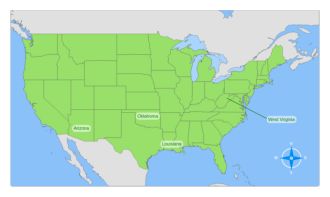

Prompt: Which of these states is farthest north?
Choices:
- West Virginia
- Louisiana
- Arizona
- Oklahoma
Answer concisely, ONLY with the correct choice.
Ground Truth: West Virginia
Model Output:  West Virginia
--------------------------------------------------


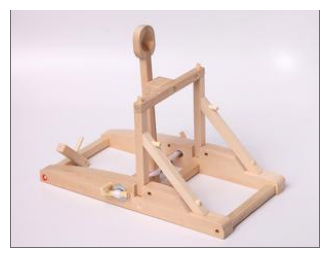

Prompt: Identify the question that Tom and Justin's experiment can best answer.
Choices:
- Do ping pong balls stop rolling along the ground sooner after being launched from a 30° angle or a 45° angle?
- Do ping pong balls travel farther when launched from a 30° angle compared to a 45° angle?
Answer concisely, ONLY with the correct choice.
Ground Truth: Do ping pong balls travel farther when launched from a 30° angle compared to a 45° angle?
Model Output: Do ping pong balls travel farther when launched from a 30° angle compared to a 45° angle?
--------------------------------------------------


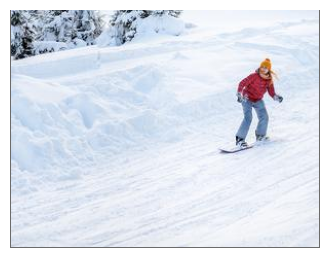

Prompt: Identify the question that Kathleen and Bryant's experiment can best answer.
Choices:
- Does Kathleen's snowboard slide down a hill in less time when it has a layer of wax or when it does not have a layer of wax?
- Does Kathleen's snowboard slide down a hill in less time when it has a thin layer of wax or a thick layer of wax?
Answer concisely, ONLY with the correct choice.
Ground Truth: Does Kathleen's snowboard slide down a hill in less time when it has a layer of wax or when it does not have a layer of wax?
Model Output: Does Kathleen's snowboard slide down a hill in less time when it has a thin layer of wax or a thick layer of wax?
--------------------------------------------------


In [5]:
model.eval()
for sample_data in prepared_samples:
    # Safely move inputs to the same device as the model
    inputs = sample_data["inputs"].to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            do_sample=False,
            max_new_tokens=256,
            pad_token_id=processor.tokenizer.eos_token_id,
            eos_token_id=processor.tokenizer.eos_token_id
    )

    # Decode ONLY the newly generated tokens to text
    input_len = inputs["input_ids"].shape[1]
    new_tokens = generated_ids[:, input_len:]
    output_text = processor.batch_decode(new_tokens, skip_special_tokens=True)[0]

    # Display results
    plt.figure(figsize=(4, 4))
    plt.imshow(sample_data["image"])
    plt.axis("off")
    plt.show()

    print(
        f"Prompt: {sample_data['prompt']}\n"
        f"Ground Truth: {sample_data['ground_truth']}\n"
        f"Model Output: {output_text}\n"
        + "-" * 50
    )

## 3. Playing with Tokens: Analyzing the Input Sequence

When a VLM encounters an image, it converts the picture into a series of 'visual tokens' and integrates them with the text tokens, forming a single prompt for the LLM.

### Task 1.3: Structural Token Analysis

Complete the cell below to inspect the input_ids tensor generated from the last processed sample. Your task is to use this tensor to calculate the exact number of visual tokens and text tokens present in the sequence.



In [6]:
input_ids = inputs.input_ids

# Find the token ID for image pads
image_token_id = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")

# Count visual tokens and text tokens
num_visual_tokens = (input_ids == image_token_id).sum().item()
num_text_tokens = input_ids.numel() - num_visual_tokens

print(f"Visual Tokens: {num_visual_tokens} | Text Tokens: {num_text_tokens}")

Visual Tokens: 70 | Text Tokens: 104


**Question 1.3a (Empirical Analysis):** Review the printed token counts from the code execution above. Calculate the exact percentage of the total input sequence length ($N$) that is occupied by the visual tokens versus the textual tokens. What does this distribution tell you about how a VLM allocates its processing capacity compared to a text-only LLM?

**Student's Answer:**



Based on the results, the model dedicates a meaningful portion ($\frac{70}{70+104} = 0.402$) of its context window to visual information. And this consumes some of the model's processing capacity (So it reduces the number of textual tokens that can be used in the same context window). We know that text-only LLMs dedicate the entire context window to textual information(as tokens). There is a trade-off here. We reduce the textual information here, but we'll be able to reason over both visual and textual information!

**Question 1.3b (Mathematical Complexity Analysis):** Consider the standard computational cost formula per forward pass for a single Transformer processing an input sequence:

$$\text{Total FLOPs} = T \times (4nd^2 + 2n^2d + 2ndm)$$

Where:

- $n$ is the sequence length (total number of tokens).
- $d$ is the model's hidden embedding dimension size.
- $m$ is the intermediate dimension size of the MLP layer.
- $T$ is the number of transformer blocks/layers.

Based on this formula and the token counts you extracted in Task 1.3, identify which specific term inside the parentheses poses the greatest computational threat when shifting from a text-only LLM to a Vision-Language Model. Explain why processing visual data scales the computational overhead so aggressively.

**Student's Answer:**


The term $2n^2d$ can be a challenge! Because it shows a quadratic relationship with $n$[$\mathcal{O}(n^2)$]. The other terms show a linear relationship. Actually, this term corresponds to the self-attention computation.

In a VLM the total sequence length is as follows:
$$ n = n_{t} + n_{v} $$
Where $n_t$ corresponds to the textual sequence length and $n_v$ corresponds to the visual sequence length. In practice adding visual information via image tokens requires increasing the total sequence length(Otherwise, [in the same sequence length] we must reduce the number of textual tokens)! 

So this increase in the term $n$ can add a serious overhead in computational cost! 

In our case, the sequence length increased from $104$ to $174$:
$$ \frac{174}{104} = 1.6731 $$
But:
$$ \frac{174^2}{104^2} = 2.7992 $$
And this is what a quadratic relationship between the computation cost and a term does!!! This is huge!!!

# S2: Dynamic Resolution and Efficient Inference

**Objective:** In this section, you will explore how Qwen processes images, manage memory and accelerate inference speed by controlling image resolution.

## 1. Dynamic Resolution Mechanism

Older Vision-Language Models required all input images to be resized or cropped to a fixed resolution before processing. Qwen utilizes a more advanced approach called Dynamic Resolution.

### Task 2.1: Dynamic Resolution

Review the official documentation or technical reports for the Qwen-VL architecture (e.g., the [Qwen2-VL Paper](https://arxiv.org/abs/2409.12191) or [Qwen2.5-VL Blog Post](https://qwen.ai/blog?id=qwen2.5-vl)). Write a brief paragraph explaining how Qwen handles images of varying sizes and aspect ratios. How does it preserve the original image structure without forcing a rigid resize?

**Student's Answer:**



As mentioned above: Older Vision-Language Models required all input images to be resized or cropped to a fixed resolution before processing. But Qwen uses a Naive Dynamic Resolution mechanism. Using this mechanism, it can process images of arbitrary sizes and aspect ratios. Actually, it dynamically converts each image into a variable number of visual tokens! So larger(also more detailed images) will produce more tokens and smaller images will produce fewer tokens. Also, Qwen uses Multimodal Rotary Position Embedding (M-RoPE) for encoding the spatial structure of the image that preserves height and width information. This allows the model to maintain original aspect ratios and layouts. Also, in this way, it  avoids the distortions (which are typical in rigid resizing or cropping).

## 2. Baseline Inference (High Resolution)

To measure the impact of resolution on speed and accuracy, we first need to establish a baseline. We will evaluate the model on 100 samples using its default, unrestricted resolution settings.

### Task 2.2a: Prepare the Evaluation Subset

Complete and run the cell below to randomly select 100 image-based questions from the ScienceQA dataset. Crucially, we extract these samples from the test split to prevent any data leakage during the training phase later.


In [6]:
test_image_data = load_dataset("derek-thomas/ScienceQA")["test"].filter(
    lambda x: x["image"] is not None
)

# Randomly sample 100 items from test_image_data (seed=42)
eval_samples = test_image_data.shuffle(seed=42).select(range(100))

### Task 2.2b: Run Baseline Evaluation

Complete the code below to run the inference loop on the 100 selected samples. We will use the standard processor from the previous section. The code includes a timer to track exactly how long the entire batch takes.


In [8]:
model.eval()
correct_predictions = 0
start_time = time.time()

for sample in eval_samples:
    ground_truth = str(sample['choices'][sample['answer']]).strip()
    choices_text = "\n".join([f"- {c}" for c in sample['choices']])
    full_prompt = f"{sample['question']}\nChoices:\n{choices_text}\nAnswer concisely, ONLY with the correct choice."
    
    # Build messages and apply chat template (disable thinking mode)
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text", "text": full_prompt}
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )

    # Process vision info and get model inputs
    image_inputs, _ = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        return_tensors="pt",
        padding=True
    )

    inputs = inputs.to(model.device)

    # Generate outputs and decode the text
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
        )

    input_len = inputs["input_ids"].shape[1]
    new_tokens = generated_ids[:, input_len:]
    output_text = processor.batch_decode(new_tokens, skip_special_tokens=True)[0]

    if ground_truth.lower() in output_text.lower():
        correct_predictions += 1

total_time_baseline = time.time() - start_time
accuracy_baseline = (correct_predictions / len(eval_samples)) * 100
print(f"Baseline (High-Res) -> Time: {total_time_baseline:.2f}s | Accuracy: {accuracy_baseline:.2f}%")

Baseline (High-Res) -> Time: 153.26s | Accuracy: 74.00%


## 3. Low-Resolution Inference

Now, we will restrict the image resolution before passing it to the model. By setting a specific `max_pixels` limit, we force the processor to generate fewer visual patches.

### Task 2.3: Re-initialize Processor and Re-evaluate

Run the cell below. It creates a new processor with a strict pixel limit and evaluates the exact same 100 samples. Observe how the time and accuracy metrics change.

(Note: The minimum acceptable resolution for `max_pixels` in this exercise is 32 * 28 * 28.)


In [9]:
# Initialize processor_low_res (max_pixels = 32 * 28 * 28)
processor_low_res = AutoProcessor.from_pretrained(
    model_id,
    max_pixels=32 * 28 * 28
)

model.eval()
correct_predictions = 0
start_time = time.time()

for sample in eval_samples:
    ground_truth = str(sample['choices'][sample['answer']]).strip()
    choices_text = "\n".join([f"- {c}" for c in sample['choices']])
    full_prompt = f"{sample['question']}\nChoices:\n{choices_text}\nAnswer concisely, ONLY with the correct choice."

    # Build messages (non-thinking mode)
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text", "text": full_prompt}
            ]
        }
    ]

    text = processor_low_res.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )

    image_inputs, _ = process_vision_info(messages)

    inputs = processor_low_res(
        text=[text],
        images=image_inputs,
        return_tensors="pt",
        padding=True
    ).to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False
        )

    input_len = inputs["input_ids"].shape[1]
    new_tokens = generated_ids[:, input_len:]
    output_text = processor_low_res.batch_decode(new_tokens, skip_special_tokens=True)[0]

    if ground_truth.lower() in output_text.lower():
        correct_predictions += 1

total_time_lowres = time.time() - start_time
accuracy_lowres = (correct_predictions / len(eval_samples)) * 100

print(f"Low-Res -> Time: {total_time_lowres:.2f}s | Accuracy: {accuracy_lowres:.2f}%")

Low-Res -> Time: 122.05s | Accuracy: 62.00%


## 4. Mathematical Complexity Analysis

You should have noticed a difference in execution time and perhaps accuracy between the baseline and the low-resolution evaluation. Let's analyze exactly why this happens.

### Task 2.4: Comparative and Root Cause Analysis

First, create a simple chart or table (you can use Python or write it directly in your text answer) comparing the execution time and accuracy between the Baseline (High Resolution) and the Low-Resolution inference.

Based on your comparison:

1. **Accuracy Change:** How did the accuracy change? If there was a drop in accuracy, was it severe (causing the model to completely lose its ability to answer correctly), or was it minimal? What conclusion can you draw from this regarding the model's visual reasoning capabilities at lower resolutions?

2. **Time Change:** Recalling the Total FLOPs formula from the previous section, explain the exact reason for the change in execution time. Why does reducing the image resolution lead to an increase in inference speed?

**Student's Answer:**


In [10]:
import pandas as pd

results_df = pd.DataFrame({
    "Setting": ["Baseline (High-Res)", "Low-Res"],
    "Time (s)": [total_time_baseline, total_time_lowres],
    "Accuracy (%)": [accuracy_baseline, accuracy_lowres]
})

results_df["Time (s)"] = results_df["Time (s)"].round(2)
results_df["Accuracy (%)"] = results_df["Accuracy (%)"].round(2)

display(results_df)

,Setting,Time (s),Accuracy (%)
0,Baseline (High-Res),153.26,74.0
1,Low-Res,122.05,62.0


- The accuracy decreased from $74\%$ to $62\%$(it drops $12\%$)! But the model can still answer more than half of the questions correctly. It shows that it retained a meaningful amount of its visual reasoning capability.

- The execution time also decreased. From $153.20 s$ to $122.05 s$ (These results are related to a specific run!). From the FLOPs formula, we have:

  $$\text{Total FLOPs} = T \times (4nd^2 + 2n^2d + 2ndm)$$

All three terms in the parentheses depend on $n$(The sequence length)! But we know that the most powerful term is $2n^2d$(we've discussed that).

- Reducing the image resolution causes a reduction in the number of visual patches(These patches are generated by the processor). So the number of visual tokens decreases! And also, the total sequence length decreases. This leads to faster inference and decreases inference time!



---

**Important Notice for the Next Section**

In the upcoming section (Section 3), we plan to fine-tune the model on the ScienceQA dataset. Because training a model requires significantly more memory (RAM/VRAM) to store gradients compared to simple inference, you are highly likely to encounter Out of Memory (OOM) errors if you attempt to train on high-resolution images.

To bypass this hardware limitation, we will be forced to decrease the image resolution during the fine-tuning process (e.g., using the `max_pixels = 32 * 28 * 28` setting).

**Crucial Note:** For your final evaluation at the end of Section 3 to be scientifically valid, the restricted resolution you utilize here in Task 2.3 must be exactly the same as the resolution you will use during the fine-tuning phase. This ensures a strictly accurate comparison between the pre-trained and fine-tuned models.

# S3: Supervised Fine-Tuning (with LoRA)

**Objective:** In this section, you will implement Low-Rank Adaptation (LoRA) to fine-tune the Qwen3.5 0.8B model. You will format multimodal data for training, configure memory-efficient training parameters, and evaluate the final fine-tuned model against your previous baseline.

## 1. Preparing the Training Data

To train the model, we need to convert the raw dataset into the exact chat structure the model expects.

### Task 3.1: Data Formatting and Structure

Complete the code below to extract a 1,000-sample subset from the ScienceQA dataset for training. Crucially, ensure this subset strictly contains image-based questions, as our goal is to train the visual reasoning capabilities of the model.

In [7]:
train_image_data = load_dataset("derek-thomas/ScienceQA")["train"].filter(
    lambda x: x['image'] is not None
)
random.seed(42)
train_subset = random.sample(list(train_image_data), 1000)

formatted_train_data = []

for sample in train_subset:
    ground_truth = str(sample['choices'][sample['answer']]).strip()
    choices_text = "\n".join([f"- {c}" for c in sample['choices']])
    full_prompt = (
        f"{sample['question']}\n"
        f"Choices:\n{choices_text}\n"
        f"Answer concisely, ONLY with the correct choice."
    )

    # Build messages list
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text", "text": full_prompt}
            ]
        },
        {
            "role": "assistant",
            "content": ground_truth
        }
    ]

    formatted_train_data.append({"messages": messages})

## 2. LoRA Configuration for VLMs

Fine-tuning an entire Vision-Language Model on standard hardware is extremely difficult due to massive memory requirements. We will use the `peft` library to apply Low-Rank Adaptation (LoRA), which freezes the base model and only trains a tiny set of injected weight matrices.

### Task 3.2: Configure PEFT

Review the Qwen3.5 architecture and standard LoRA practices. You need to identify which specific layers within the Large Language Model component should be targeted for adaptation. Do not target the Vision component layers.


In [8]:
from peft import LoraConfig, get_peft_model

# Configure LoRA (target ONLY LLM layers)
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

# Apply PEFT
model = get_peft_model(model, peft_config)

# Print trainable parameters
model.print_trainable_parameters()

trainable params: 6,389,760 || all params: 859,375,680 || trainable%: 0.7435


## 3. The Training Loop

We will use Hugging Face's `Trainer` mapped for VLMs to handle the training loop. Because training memory footprint is heavily dependent on sequence length, we must strictly manage hardware constraints. To make the process clear, we will break the training setup into three smaller steps.

### Task 3.3a: Setup the Processor and Data Collator

Complete and run the cell below to load our restricted-resolution processor and define a custom `DataCollator` that processes multimodal inputs dynamically during training.


In [9]:
# Load low-res processor for memory efficiency during training
processor_train = AutoProcessor.from_pretrained(
    model_id,
    max_pixels=32 * 28 * 28
)

def multimodal_data_collator(features):
    texts, images = [], []

    for feature in features:
        # Apply chat template and extract vision info
        text = processor_train.apply_chat_template(
            feature["messages"],
            tokenize=False,
            add_generation_prompt=False,
            enable_thinking=False
        )

        image_inputs, _ = process_vision_info(feature["messages"])

        texts.append(text)
        if image_inputs:
            images.extend(image_inputs)

    # Process batch using processor_train
    batch = processor_train(
        text=texts,
        images=images if len(images) > 0 else None,
        return_tensors="pt",
        padding=True
    )

    # Set labels for Causal LM
    batch["labels"] = batch["input_ids"].clone()

    return batch

### Task 3.3b: Configure Training Arguments

The acceptable training configurations are specified within the code comments below. If your hardware encounters memory limitations (such as Out of Memory errors) or exceptionally slow training times, you should lower these parameters accordingly to successfully complete the fine-tuning process. Run the cell below to configure them.




In [10]:
training_args = TrainingArguments(
    output_dir="./qwen_vlm_lora",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=2e-4,
    num_train_epochs=1,
    logging_steps=10,
    save_steps=200,
    save_total_limit=2,
    fp16=True,
    bf16=False,
    report_to="none",
    optim="adamw_torch",
    dataloader_pin_memory=False,
    remove_unused_columns=False
)

### Task 3.3c: Initialize Trainer and Execute

Run the cell below to piece everything together into the `Trainer` and start the Fine-Tuning process.


In [11]:
# Initialize Trainer with model, args, dataset, and collator
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=formatted_train_data,
    data_collator=multimodal_data_collator,
)

# Start training
trainer.train()

# Save the fine-tuned model
trainer.save_model("./qwen_vlm_lora_final")

Step,Training Loss
10,7.203064
20,3.079100
30,1.666830
40,1.325572
50,1.205560
60,1.171367


## 4. Secondary Evaluation

With the model fine-tuned, it is time to measure the impact of our training. We will evaluate the fine-tuned model using the exact same evaluation dataset and settings from Section 2.

### Task 3.4: Evaluate the Fine-Tuned Model

Run the exact same 100 evaluation samples from Task 2.2 using the newly fine-tuned model and the restricted low-resolution processor.



In [12]:
model.eval()

correct_predictions = 0
start_time = time.time()

for sample in eval_samples:
    ground_truth = str(sample['choices'][sample['answer']]).strip()
    choices_text = "\n".join([f"- {c}" for c in sample['choices']])
    full_prompt = (
        f"{sample['question']}\nChoices:\n{choices_text}\n"
        f"Answer concisely, ONLY with the correct choice."
    )

    # Build messages (low-res + fine-tuned model)
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text", "text": full_prompt}
            ]
        }
    ]

    # Apply low-res processor used in training
    text = processor_train.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )

    image_inputs, _ = process_vision_info(messages)

    inputs = processor_train(
        text=[text],
        images=image_inputs,
        return_tensors="pt",
        padding=True
    ).to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False
        )

    input_len = inputs["input_ids"].shape[1]
    new_tokens = generated_ids[:, input_len:]
    output_text = processor_train.batch_decode(new_tokens, skip_special_tokens=True)[0]

    if ground_truth.lower() in output_text.lower():
        correct_predictions += 1

total_time_finetuned = time.time() - start_time
accuracy_finetuned = (correct_predictions / len(eval_samples)) * 100

print(f"Fine-Tuned (Low-Res) -> Time: {total_time_finetuned:.2f}s | Accuracy: {accuracy_finetuned:.2f}%")

Fine-Tuned (Low-Res) -> Time: 80.90s | Accuracy: 72.00%


# S4: Critical Analysis
---

### Task 4.1: The Tripartite Trade-off

Throughout this exercise, you have gathered metrics for three distinct states of the model. Fill in the comparison table below with the data you collected:

| Model State | Resolution (max_pixels) | Total Inference Time (s) | Accuracy (%) |
| --- | --- | --- | --- |
| **A) Baseline (High Res)** | Default (Unrestricted) | 153.26 | 74  |
| **B) Baseline (Low Res)** | 32 * 28 * 28 | 122.05 | 62 |
| **C) Fine-Tuned (Low Res)** | 32 * 28 * 28 | 80.90  | 72 |

Based on the data in your table, analyze the "Speed-Accuracy Trade-off." Did the computational time and effort spent fine-tuning the model in Section 3 justify the final inference speed and accuracy achieved in state (C)?

**Student's Answer:**


- There is a clear Speed-Accuracy Trade-off across the three states.
- A vs B: As mentioned before, reducing the resolution decreases inference time, but decreases the accuracy too! So reducing the number of visual tokens improves efficiency. But it also weakens the model's ability.
- B vs C: Fine-tuning decreases the inference time in C significantly! But the accuracy increases. This means fine-tuning with LoRA compensates for the loss of visual information(caused by lowering the resolution). So not only does fine-tuning with LoRA maintain efficiency, but it also increases the model's power!
- A vs C: The fine-tuned low-resolution model and the base model achieved nearly the same accuracy! But the inference time in C was much lower! So the fine-tuning is highly justified. It makes the model operate more efficiently without any significant drop in performance!
- We conclude that regime C has the best trade-off between speed and performance. So regime C is the desirable configuration.

---

### Task 4.2: Understanding Visual Redundancy
Look at your table from Task 4.1 and compare the rate of change in resolution versus the rate of change in accuracy when moving from State (A) to State (B). 

In machine learning, this specific behavior is related to the concept of data "redundancy." Based on your results, explain what visual redundancy means. Why can a model still logically process an image after losing a massive percentage of its visual patches, whereas dropping the exact same percentage of words from a text prompt would completely destroy its meaning?

**Student's Answer:**



As mentioned before, moving from State (A) to State (B), reducing the resolution decreases inference time(significantly), but decreases the accuracy too(moderately from $74\%$ to $62\%$)! This is actually because images contain visual redundancy. It means that neighboring patches often have similar information. So if we remove many patches, the overall objects and scene structures will be preserved! For text, there is a subtle difference! Text has much less redundancy. So removing the same proportion of words can delete some key information. It can even break the grammar! So this makes the prompt hard to understand(in some cases, impossible to understand). 

### Task 4.3: Exploring the Frontiers of Efficiency

In this exercise, we relied heavily on "Dynamic Resolution Reduction" to fit the VLM inference and training onto constrained hardware. However, this is just one approach in the broader field of efficient AI.

Research the current literature on Large Vision-Language Models. Identify and name at least **two other techniques** used to accelerate inference and reduce memory (VRAM) consumption. Provide a concise, one-sentence explanation of the core mechanism for each technique.

**Student's Answer:**


- Quantization: This approach reduces the precision of model weights and activations (For example: from FP16 to INT8 or INT4). This lowers VRAM usage and accelerates inference.
- KV Cache: This approach stores the key and value tensors computed during previous decoding steps. These stored materials can be reused(No recomputation).

### Task 4.4: Task-Specific Resolution Sensitivity
In our experiment, you saw how reducing the resolution affected the accuracy on the ScienceQA dataset. Do you think this result would be the same for all types of visual tasks? 

Compare the ScienceQA dataset to a dataset focused on reading dense charts, complex graphs, or document text (e.g., ChartQA or DocVQA). How would extreme resolution reduction affect the accuracy in those cases, and why? 

*(Note: You do not need to write code or run any tests for this question. Just provide your analytical opinion).*

**Student's Answer:**



No! ScienceQA requires understanding the overall objects and scene structures(as we mentioned before). So after reducing the resolution it often preserves enough information. But in datasets such as **ChartQA** or **DocVQA** there are some fine-grained details. Many of their records have small text, numbers and chart elements. If we extremely reduce the resolution, these details will be removed. So there will be a much larger drop in accuracy and the model will not be able to read some necessary visual information!

## Note: I used ChatGPT, GapGPT and DeepSeek to help me understand and complete the tasks. Before starting this assignment, I was not familiar with the pipeline of *VLM* systems. The final code (and analysis) was developed based on my own ideas and my internet searches, with additional help and guidance from these tools.